compare the E2 and E3 compartments:
- E2:
  - room temperature at 1 bar
  - heated at 1 bar
- E3:
  - room temperature at 1 bar
  - heated at 1 bar
  - room temperature at 4 bar
  - heated at 4 bar

In [10]:
from pathlib import Path
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting_5 import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import matplotlib as mpl
import ICIW_Plots
import numpy as np
import torch


plt.style.use(["ICIWstyle"])
plt.rcParams.update({"font.size": 7})

In [11]:
runs = [
    {
        "ID": "nx6hue2t",
        "p": 1,
        "T": 25 + 273.15,
    },
    {
        "ID": "e07rassz",
        "p": 4,
        "T": 25 + 273.15,
    },
    {
        "ID": "40app8ou",
        "p": 1,
        "T": 250 + 273.15,
    },
    {
        # "ID": "ozukvsff",  # 12.9 s offset
        # "ID": "qzzaaba", # 12.9 - 0.25 s offset
        "ID": "544su10u",  # 12.9 - 0.5 s offset
        "p": 4,
        "T": 250 + 273.15,
    },
]

for config in runs:
    name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{config["ID"]}")
    model = RTDModule.load_from_checkpoint(ckpt_path)
    config["model"] = model
    config["E"] = [E.numpy() for E in model.net.E]

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [12]:
runs[0]["E"][0]

array([9.52818024e-04, 8.79094412e-04, 8.02200404e-04, 6.63319544e-04,
       5.83303743e-04, 5.55329956e-04, 4.71570005e-04, 4.02218371e-04,
       4.11396119e-04, 4.09763423e-04, 3.73781950e-04, 4.08342836e-04,
       5.23783558e-04, 6.44457061e-04, 8.66508635e-04, 1.34131685e-03,
       1.07303150e-01, 2.49335647e-01, 3.75310004e-01, 4.52529430e-01,
       4.53843594e-01, 3.98195595e-01, 3.25440258e-01, 2.56370306e-01,
       1.96440801e-01, 1.53159514e-01, 1.27224252e-01, 1.07568346e-01,
       8.82257819e-02, 7.61527419e-02, 6.78534806e-02, 5.54535873e-02,
       4.59843986e-02, 4.21186611e-02, 3.65698077e-02, 2.87263282e-02,
       2.51258239e-02, 2.38976981e-02, 1.89115126e-02, 1.51635008e-02,
       1.56105682e-02, 1.37442015e-02, 9.48157161e-03, 8.60694144e-03,
       1.06284367e-02, 8.97817127e-03, 6.86821295e-03, 8.81770812e-03,
       9.54727177e-03, 6.51499862e-03, 5.91311790e-03, 8.41930974e-03,
       7.35153770e-03, 4.11965791e-03, 6.40964787e-03, 8.21945630e-03,
      

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Hannes\AppData\Local\Temp\ipykernel_11428\2702795049.py:20: SyntaxWarning: invalid escape sequence '\m'
  label=f"$p = {conf['p']} \mathrm{{bar}}, T = {T_show} \mathrm{{K}}$",
C:\Users\Hannes\AppData\Local\Temp\ipykernel_11428\2702795049.py:20: SyntaxWarning: invalid escape sequence '\m'
  label=f"$p = {conf['p']} \mathrm{{bar}}, T = {T_show} \mathrm{{K}}$",


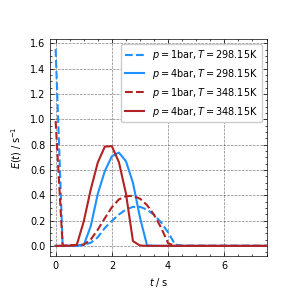

In [13]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E(t)\;/\;\mathrm{s}^{-1}$",
    xlim=(-0.2, 7.5),
)

for conf in runs:
    E = conf["E"][2]
    t = conf["model"].net.conv_layers[2].t_kernel.detach().numpy()
    color = "firebrick" if conf["T"] == 273.15 + 250 else "dodgerblue"
    T_show = conf["T"] - 250 + 75 if conf["T"] == 273.15 + 250 else conf["T"]
    linestyle = "--" if conf["p"] == 1 else "-"
    ax.plot(
        t,
        E,
        label=f"$p = {conf['p']} \mathrm{{bar}}, T = {T_show} \mathrm{{K}}$",
        color=color,
        linestyle=linestyle,
    )

ax.legend()

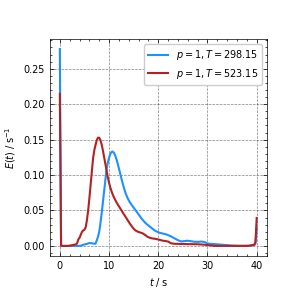

In [14]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E(t)\;/\;\mathrm{s}^{-1}$",
)

for conf in runs:
    E = conf["E"][1]
    t = conf["model"].net.conv_layers[1].t_kernel.detach().numpy()
    color = "firebrick" if conf["T"] == 273.15 + 250 else "dodgerblue"
    if conf["p"] == 4:
        continue
    ax.plot(t, E, label=f"$p = {conf['p']}, T = {conf['T']}$", color=color)

ax.legend()